In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("ahmedelsany/car-brand-classification-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 177M/177M [00:10<00:00, 17.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1):
['Car Brand Classification Dataset']


In [ ]:
print(f"Contents of the 'train' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'train'))}")
print(f"Contents of the 'test' directory: {os.listdir(os.path.join(path, 'Car Brand Classification Dataset', 'test'))}")

Contents of the 'train' directory: ['BMW', 'Ford', 'INFINITI', 'Lincoln', 'Kia', 'FIAT', 'Jaguar', 'Volvo', 'Mercedes-Benz', 'Jeep', 'Chevrolet', 'Buick', 'Toyota', 'MINI', 'Honda', 'Nissan', 'Aston Martin', 'Land Rover', 'Porsche', 'Hyundai', 'Mitsubishi', 'Lexus', 'Subaru', 'Acura', 'Dodge', 'Mazda', 'Chrysler', 'Cadillac', 'GMC', 'Audi', 'Volkswagen', 'Ram', 'Bentley']
Contents of the 'test' directory: ['BMW', 'Ford', 'INFINITI', 'Lincoln', 'Kia', 'FIAT', 'Jaguar', 'Volvo', 'Mercedes-Benz', 'Jeep', 'Chevrolet', 'Buick', 'Toyota', 'MINI', 'Honda', 'Nissan', 'Aston Martin', 'Land Rover', 'Porsche', 'Hyundai', 'Mitsubishi', 'Lexus', 'Subaru', 'Acura', 'Dodge', 'Mazda', 'Chrysler', 'Cadillac', 'GMC', 'Audi', 'Volkswagen', 'Ram', 'Bentley']



--- Sample Images from Training Dataset (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/train) ---
Found 11517 images in /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/train. Displaying 6 samples:


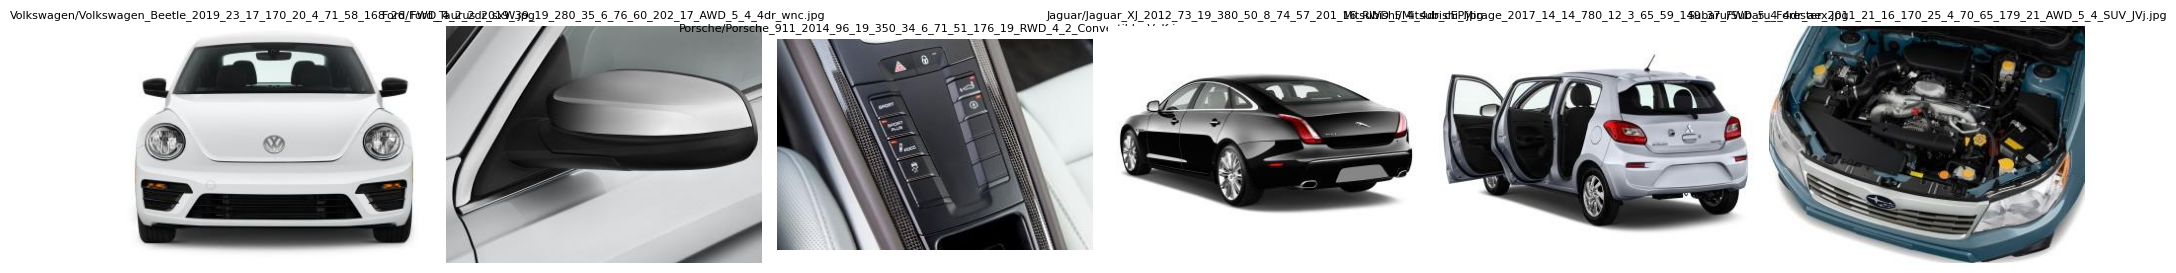


--- Sample Images from Test Dataset (/root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/test) ---
Found 2475 images in /root/.cache/kagglehub/datasets/ahmedelsany/car-brand-classification-dataset/versions/1/Car Brand Classification Dataset/test. Displaying 6 samples:


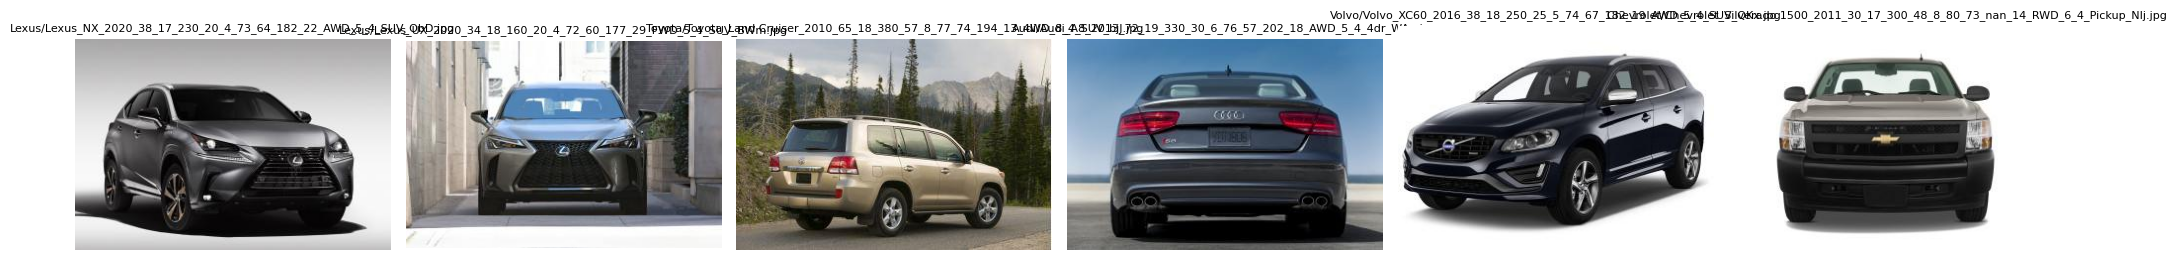

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(os.path.dirname(img_path)) + '/' + os.path.basename(img_path), fontsize=8)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to include 'Car Brand Classification Dataset' subdirectory
train_path = os.path.join(path, 'Car Brand Classification Dataset', 'train')
print(f"\n--- Sample Images from Training Dataset ({train_path}) ---")
display_sample_images(train_path)

test_path = os.path.join(path, 'Car Brand Classification Dataset', 'test')
print(f"\n--- Sample Images from Test Dataset ({test_path}) ---")
display_sample_images(test_path)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# 1. Check GPU Availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
# 2. Define Data Augmentation and Loaders
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(train_path, data_transforms['train']),
    'test': datasets.ImageFolder(test_path, data_transforms['test'])
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2)
    for x in ['train', 'test']
}

# 3. Build ResNet Model
model = models.resnet18(weights='DEFAULT')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(image_datasets['train'].classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Training Loop
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
num_epochs = 10

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    for phase in ['train', 'test']:
        if phase == 'train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(image_datasets[phase])
        epoch_acc = running_corrects.double() / len(image_datasets[phase])

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


Epoch 1/10
train Loss: 3.4199 Acc: 0.0753
test Loss: 3.5884 Acc: 0.0638
Epoch 2/10
train Loss: 3.0720 Acc: 0.1463
test Loss: 2.9671 Acc: 0.1737
Epoch 3/10
train Loss: 2.7413 Acc: 0.2318
test Loss: 2.9269 Acc: 0.2141
Epoch 4/10
train Loss: 2.4042 Acc: 0.3249
test Loss: 2.7043 Acc: 0.2537
Epoch 5/10
train Loss: 2.0636 Acc: 0.4142
test Loss: 2.2560 Acc: 0.3762
Epoch 6/10
train Loss: 1.7395 Acc: 0.5083
test Loss: 3.2592 Acc: 0.2638
Epoch 7/10
train Loss: 1.4482 Acc: 0.5841
test Loss: 2.1266 Acc: 0.4481
Epoch 8/10
train Loss: 1.1199 Acc: 0.6761
test Loss: 2.2280 Acc: 0.4545
Epoch 9/10
train Loss: 0.8835 Acc: 0.7457
test Loss: 2.1380 Acc: 0.4909
Epoch 10/10
train Loss: 0.6672 Acc: 0.8063
test Loss: 2.4129 Acc: 0.4889


In [ ]:
# 5. Summary of Results
print("--- Training Summary ---")
print(f"Final Training Accuracy: {history['train_acc'][-1]:.4f}")
print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}")
print(f"Best Test Accuracy: {max(history['test_acc']):.4f}")

--- Training Summary ---
Final Training Accuracy: 0.8063
Final Test Accuracy: 0.4889
Best Test Accuracy: 0.4909


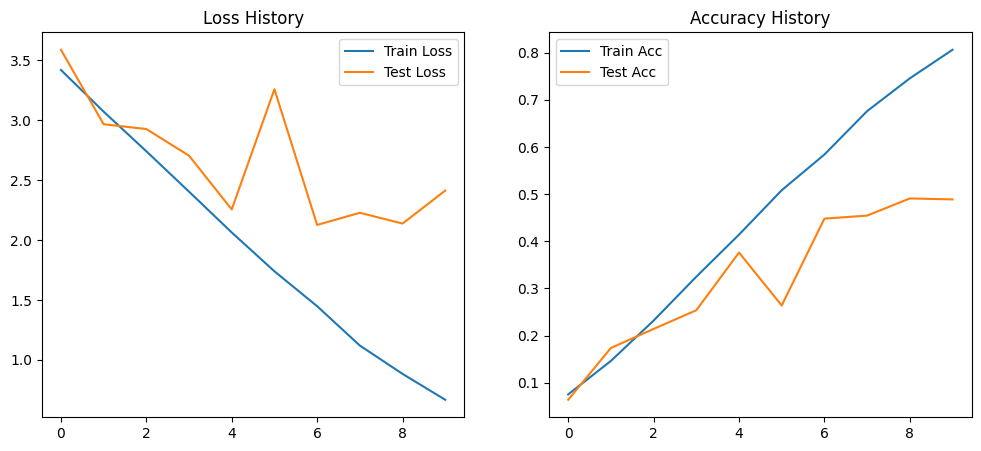

In [ ]:
# 6. Display Training Charts
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Accuracy History')
plt.legend()

plt.show()